In [4]:
# import pandas as pd
# import numpy as np
# import os

# os.path.exists("../EDA Projects/Movie_EDA_Analysis/dataset/movies.csv")
# for google collab
from google.colab import files
uploaded = files.upload()

# movie_raw_data = pd.read_csv("../dataset/movies.csv")
# movie_raw_data.head()

# movie_raw_data = pd.read_csv("../EDA Projects/Movie_EDA_Analysis/dataset/movies.csv")

Saving movies.csv to movies.csv


In [1]:
import pandas as pd
import numpy as np

# for local
movie_raw_data = pd.read_csv("../dataset/movies.csv")

# for collab
# movie_raw_data=pd.read_csv(list(uploaded.keys())[0])
movie_raw_data.head()



,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


In [2]:

movie_raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 4803 non-null   int64  
 1   budget                4803 non-null   int64  
 2   genres                4775 non-null   object 
 3   homepage              1712 non-null   object 
 4   id                    4803 non-null   int64  
 5   keywords              4391 non-null   object 
 6   original_language     4803 non-null   object 
 7   original_title        4803 non-null   object 
 8   overview              4800 non-null   object 
 9   popularity            4803 non-null   float64
 10  production_companies  4803 non-null   object 
 11  production_countries  4803 non-null   object 
 12  release_date          4802 non-null   object 
 13  revenue               4803 non-null   int64  
 14  runtime               4801 non-null   float64
 15  spoken_languages     

In [3]:
# Check with null,missing and unrealistic values for revenue column
# checking 0 revenue movies
no_revenue = movie_raw_data[movie_raw_data['revenue']== 0 ]
no_revenue.head(10)
zero_rev_count = no_revenue.shape[0]
total_movies = movie_raw_data.shape[0]

print(zero_rev_count, total_movies)

zero_rev_perc = (zero_rev_count/total_movies)*100
print(zero_rev_perc)

print(no_revenue[['budget', 'revenue']].describe())
print(movie_raw_data[movie_raw_data['revenue'] > 0]['budget'].describe())
print(movie_raw_data[['budget', 'revenue']].describe())

no_revenue.head(10)
no_revenue['genres'].value_counts().head(10)

print(movie_raw_data['revenue'].mean(),"mean", movie_raw_data['revenue'].median(),"median")
print(no_revenue['revenue'].mean(),"mean", movie_raw_data['revenue'].median(),"median")
# movie_raw_data[movie_raw_data['revenue'] > 0]['revenue'].mean(),
# movie_raw_data[movie_raw_data['revenue'] > 0]['revenue'].median()

# Also,Approximately 30% [29.710597543202166] [1427]of movies have zero reported revenue. Budget analysis shows that many of these films
#  had non-zero production budgets, indicating missing financial reporting rather than true zero earnings.
#  Therefore, movies with zero revenue were excluded from revenue and profitability analyses but retained
#  for audience engagement and content-based insights.


# created movie_finance where revenue 0 movies are excluded for clean data for profit,finance,budget purpose
movie_finanace = movie_raw_data[movie_raw_data['revenue'] > 0]
movie_finanace.head(5)


1427 4803
29.710597543202166
             budget  revenue
count  1.427000e+03   1427.0
mean   5.767431e+06      0.0
std    1.371360e+07      0.0
min    0.000000e+00      0.0
25%    0.000000e+00      0.0
50%    0.000000e+00      0.0
75%    4.000000e+06      0.0
max    1.500000e+08      0.0
count    3.376000e+03
mean     3.888424e+07
std      4.420490e+07
min      0.000000e+00
25%      8.500000e+06
50%      2.500000e+07
75%      5.200000e+07
max      3.800000e+08
Name: budget, dtype: float64
             budget       revenue
count  4.803000e+03  4.803000e+03
mean   2.904504e+07  8.226064e+07
std    4.072239e+07  1.628571e+08
min    0.000000e+00  0.000000e+00
25%    7.900000e+05  0.000000e+00
50%    1.500000e+07  1.917000e+07
75%    4.000000e+07  9.291719e+07
max    3.800000e+08  2.787965e+09
82260638.65167603 mean 19170001.0 median
0.0 mean 19170001.0 median


,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


Also,Approximately 30% [29.710597543202166] [1427]of movies have zero reported revenue. Budget analysis shows that many of these films
 had non-zero production budgets, indicating missing financial reporting rather than true zero earnings.
 Therefore, movies with zero revenue were excluded from revenue and profitability analyses but retained
 for audience engagement and content-based insights.

In [ ]:
# We start with genere analysis
# considering --> who watches it, how risky it is, and whether it reliably makes money?
# Demand = audience interest + market performance + production behavior


# counting genre combinations, not genres
movie_raw_data['genres'].value_counts()
print(movie_raw_data['genres'].isna().sum())

# The genres column contains 28 missing values (~0.6% of the dataset). 
# These entries were excluded from genre-level analysis. 
# No numeric placeholders such as zero were used to represent missing genres


# creating seperate dataframe for genres to analyze also dropping na

genre_data = movie_raw_data.dropna(subset=['genres']).copy()

# Split multi-genres
genre_df['genres'] = genre_df['genres'].str.split('|')

# Explode → one genre per row
genre_df = genre_df.explode('genres')

genre_df.head()

# Check with Popularity and count

genre_engagement = (
    genre_df
    .groupby('genres')
    .agg(
        movie_count=('title', 'count'),
        avg_vote=('vote_average', 'mean'),
        median_vote=('vote_average', 'median'),
        avg_popularity=('popularity', 'mean'),
        avg_vote_count=('vote_count', 'mean')
    )
    .sort_values('movie_count', ascending=False)
)


# below is the highest popularity and genre for the same [high engadgement and low count]

high_eng = genre_engagement['avg_popularity'].quantile(0.75)
low_eng = genre_engagement['avg_popularity'].quantile(0.25)

high_count = genre_engagement['avg_vote_count'].quantile(0.75)
low_count = genre_engagement['avg_vote_count'].quantile(0.25)


# will check with high count low engadgement
high_count_low_eng = genre_engagement[
    (genre_engagement['avg_popularity']<=low_eng)&
    (genre_engagement['avg_vote_count']>=high_count)
]
print(high_count_low_eng,"High count low engadgement")

# will check with low count  high engadgement
low_count_high_eng = genre_engagement[
    (genre_engagement['avg_popularity']>=high_eng)&
    (genre_engagement['avg_vote_count']<=low_count)
]
print(low_count_high_eng,"Low count High engadgement")
# There is no such val/genres where count is low and popularity is high



28
                                         movie_count  avg_vote  median_vote  \
genres                                                                        
Action Adventure Horror Science Fiction            1       5.8          5.8   

                                         avg_popularity  avg_vote_count  
genres                                                                   
Action Adventure Horror Science Fiction        2.143764          1363.0   High count low engadgement
Empty DataFrame
Columns: [movie_count, avg_vote, median_vote, avg_popularity, avg_vote_count]
Index: [] Low count High engadgement


In [73]:
# checking with financial viability ------------->
# ROI = 
# here we took budget and revenue more than 0 as previously tried without below check it is gettin inf so as per roi formula below is the valid data 
valid_movies = movie_finanace[
    (movie_finanace['budget'] > 0) & 
    (movie_finanace['revenue'] > 0)
]

genres_finance = (
    valid_movies
    .groupby('genres')
    .agg(
        median_revenue = ('revenue','median'),
        median_budget = ('budget','median'),
        mean_revenue = ('revenue','mean')
    )
)
genres_finance['ROI'] = (
    (genres_finance['median_revenue'] - genres_finance['median_budget']) 
    / genres_finance['median_budget']
)

# CURRENTLY WITH ABOVE ROI DATA IS MISLEADING SO ENEED TO REGULATE - applying minimum budget threshold 

filtered_data = movie_finanace[
    (movie_finanace['budget'] > 1_000_000) & 
    (movie_finanace['revenue'] > 0)
]

genres_finance_filtered = (
    filtered_data
    .groupby('genres')
    .agg(
        median_revenue = ('revenue','median'),
        median_budget = ('budget','median'),
        mean_revenue = ('revenue','mean')
    )
)
genres_finance_filtered['ROI'] = (
    (genres_finance_filtered['median_revenue'] - genres_finance_filtered['median_budget']) 
    / genres_finance_filtered['median_budget']
)

genres_finance_filtered.sort_values('ROI', ascending=False).head(10)

# genres_finance.sort_values('ROI', ascending=False).head(10)
# movie_finanace['budget']

,median_revenue,median_budget,mean_revenue,ROI
genres,,,,
Horror Mystery Crime,103911669.0,1200000.0,103911669.0,85.593058
Science Fiction Adventure Family Fantasy,792910554.0,10500000.0,792910554.0,74.515291
Horror Thriller Adventure,470654000.0,7000000.0,470654000.0,66.236286
Western Comedy,119500000.0,2600000.0,119500000.0,44.961538
Action Romance War,356830601.0,15000000.0,356830601.0,22.788707
Drama War Action,138530565.0,6000000.0,138530565.0,22.088428
Adventure Comedy Science Fiction Family,381109762.0,19000000.0,381109762.0,19.058409
Comedy Family Adventure Crime,358991681.0,18000000.0,358991681.0,18.943982
Adventure Drama Western,424208848.0,22000000.0,424208848.0,18.282220


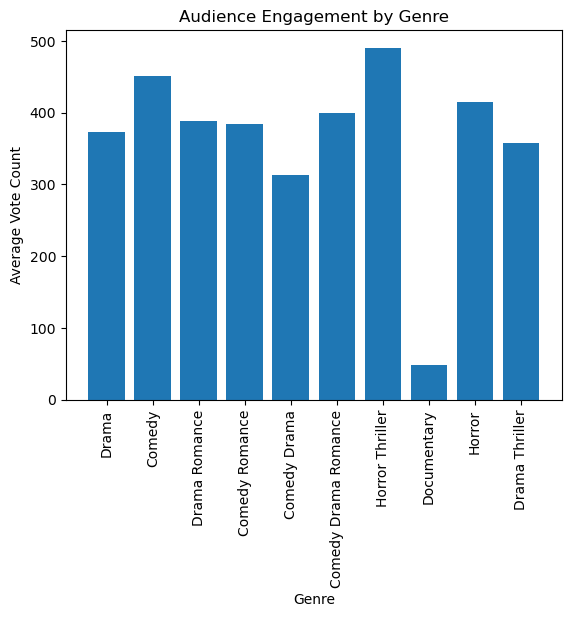

In [80]:
import matplotlib.pyplot as plt

top_genres = genre_engagement.sort_values('movie_count', ascending=False).head(10)

plt.figure()
plt.bar(top_genres.index, top_genres['avg_vote_count'])
plt.xticks(rotation=90)
plt.title('Audience Engagement by Genre')
plt.ylabel('Average Vote Count')
plt.xlabel('Genre')
plt.show()


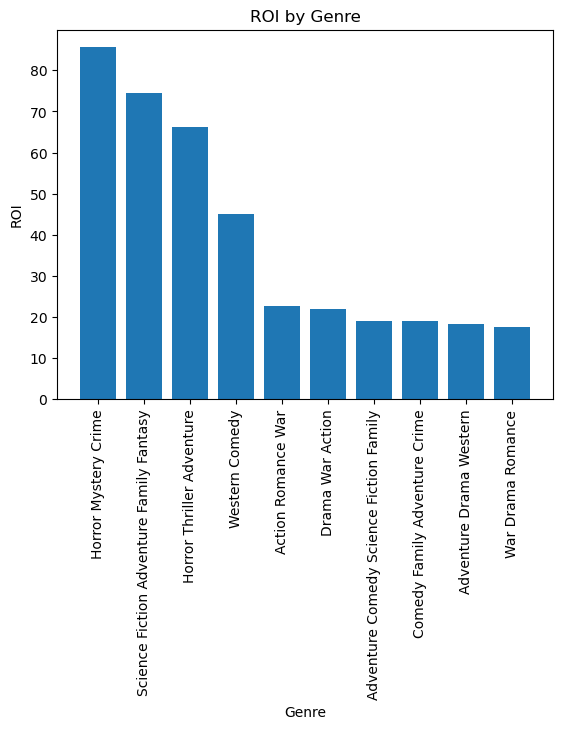

In [78]:
import matplotlib.pyplot as plt

top_genres = genres_finance_filtered.sort_values('ROI', ascending=False).head(10)

plt.figure()
plt.bar(top_genres.index, top_genres['ROI'])
plt.xticks(rotation=90)
plt.title('ROI by Genre')
plt.ylabel('ROI')
plt.xlabel('Genre')
plt.show()
